In [68]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import h5py
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
# from synthetic_observations import Observations
from realstar_synthetic_observations import Observations

from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA
from matplotlib import gridspec



In [69]:
df = pd.read_pickle("../data/training_data/SPIRou20_train.df")
bphoenix = df[(df['teff']==3200)&(df['logg']==5.0)&(df['metal']==-0.5)]['Broadened'].iloc[0]
pphoenix = df[(df['teff']==2900)&(df['logg']==5.0)&(df['metal']==0.0)]['Broadened'].iloc[0]

In [70]:
o=20
df = pd.read_pickle("../data/training_data/SPIRou"+str(o)+"_train.df")
non_ones = np.where(df['Wavelength'].iloc[0] != 1)[0]
flux = np.vstack(df['Final'].to_numpy())
flux = flux[:,non_ones]
mean, std = np.mean(flux,axis=0), np.std(flux,axis=0)
df = []

In [71]:
import h5py
import os
import re

folder = "../barnards/results"   # your results folder
barnard_data = {}        # keyed by (snr, nspec)

for filename in os.listdir(folder):
    if filename.startswith("moresamp"):
        filepath = os.path.join(folder, filename)
        with h5py.File(filepath, "r") as f:
            # Read observational params
            i = f['Order']['Observational Parameters'].attrs['i']
            snr = f['Order']['Observational Parameters'].attrs['snr']
            nspec = f['Order']['Observational Parameters'].attrs['nspec']

            # Spectrum (optional, if you need it)
            spectrum_group = f['Order']['Observational Parameters']['Spectrum']
            spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}

            # Store under (snr, nspec, step)
            barnard_data[(i, snr, nspec)] = {
                "spectrum": spectrum_analysis,
            }

            wgrid = f['Order']['wgrid'][:] 
            non_ones = f['Order']['non_ones'][:] 
            inst_wgrid = f['Order']['inst_wgrid'][:]
wgrid, non_ones, inst_wgrid

(array([1280.74924137, 1280.75137595, 1280.75351053, ..., 1321.24599313,
        1321.2481952 , 1321.25039728]),
 array([    3,     4,     5, ..., 18681, 18682, 18683]),
 array([1280.74924137, 1280.76036661, 1280.77149125, ..., 1321.23188317,
        1321.24058238, 1321.24928099]))

(1293.0, 1294.0)

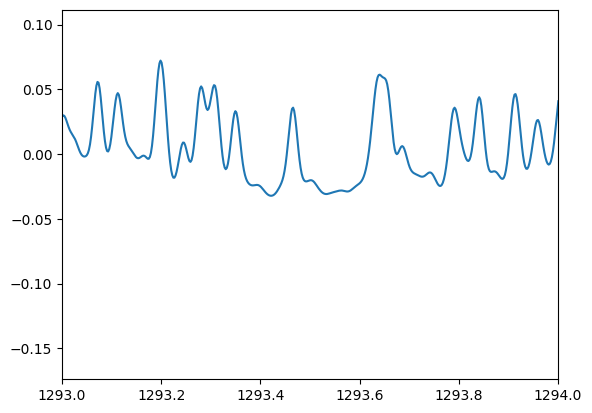

In [72]:
plt.plot(wgrid,bphoenix-pphoenix)
plt.xlim(1293,1294)

In [73]:
import h5py
import os
import re

folder = "../proxima/results"   # your results folder
proxima_data = {}        # keyed by (snr, nspec)

for filename in os.listdir(folder):
    if filename.startswith("moresamp"):
        filepath = os.path.join(folder, filename)
        with h5py.File(filepath, "r") as f:
            # Read observational params
            i = f['Order']['Observational Parameters'].attrs['i']
            snr = f['Order']['Observational Parameters'].attrs['snr']
            nspec = f['Order']['Observational Parameters'].attrs['nspec']

            # Spectrum (optional, if you need it)
            spectrum_group = f['Order']['Observational Parameters']['Spectrum']
            spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}
            
            # Store under (snr, nspec, step)
            proxima_data[(i, snr, nspec)] = {
                "spectrum": spectrum_analysis,
            }

            wgrid = f['Order']['wgrid'][:] 
            non_ones = f['Order']['non_ones'][:] 
            inst_wgrid = f['Order']['inst_wgrid'][:]
wgrid, non_ones, inst_wgrid

(array([1280.74924137, 1280.75137595, 1280.75351053, ..., 1321.24599313,
        1321.2481952 , 1321.25039728]),
 array([    3,     4,     5, ..., 18681, 18682, 18683]),
 array([1280.74924137, 1280.76036661, 1280.77149125, ..., 1321.23188317,
        1321.24058238, 1321.24928099]))

In [74]:
start = int(0.005*wgrid.shape[-1])
end = int(0.995*wgrid.shape[-1])

s1 = int(0.005*inst_wgrid.shape[-1])
e1 = int(0.995*inst_wgrid.shape[-1])

start = np.searchsorted(wgrid, inst_wgrid[s1])
end = np.searchsorted(wgrid, inst_wgrid[e1])

In [75]:
proxima = proxima_data[(0,10,10)]['spectrum']
barnards =barnard_data[(0,10,10)]['spectrum']

In [76]:
proxima['template'].shape

(18681,)

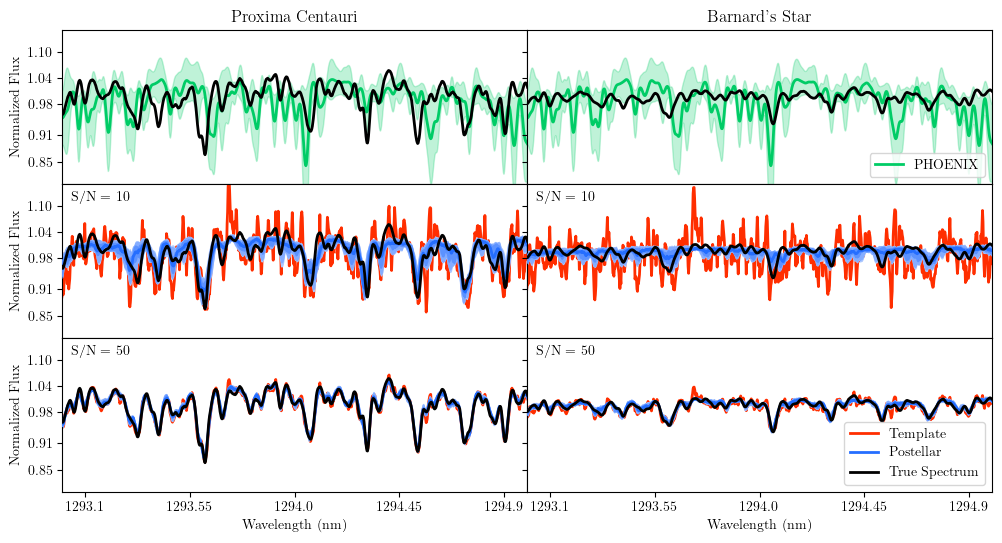

In [82]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

fig, axs = plt.subplots(3, 2, figsize=(12,6), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0, wspace=0)

template_color   = "#FF2E00"   # warm tone
postellar_color  = "#256EFF"
onesig = "#5C92FF"
twosig = "#85ADFF"
threesig = "#ADC9FF"   # cool tone

def plot_system(ax, system, data_dict):
    data = data_dict[system]['spectrum']
    wavelength = wgrid[start:end]
    true_spec  = data['true_spectrum'][0,0][start:end]
    template   = data['template'][start:end]

    post = data['posterior_spectrum_samples'][:,:,0,non_ones[0]:non_ones[-1]+1][:,:,start:end]
    mean_post = np.percentile(post, 50, axis=(0,1))
    sig1 = np.percentile(post, [16, 84],      axis=(0,1))
    sig2 = np.percentile(post, [2.5, 97.5],   axis=(0,1))
    sig3 = np.percentile(post, [0.15, 99.85], axis=(0,1))

    ax.plot(wavelength, template, color=template_color, label="Template",lw=2,zorder=0)
    ax.plot(wavelength, mean_post, color=postellar_color, label="Postellar",lw=2,zorder=4)
    ax.plot(wavelength, true_spec, color='black', label="True Spectrum",lw=2,zorder=5)


    ax.fill_between(wavelength, sig3[0], sig3[1], color=threesig,zorder=1)
    ax.fill_between(wavelength, sig2[0], sig2[1], color=twosig,zorder=2)
    ax.fill_between(wavelength, sig1[0], sig1[1], color=onesig,zorder=3)
    ax.text(0.02, 0.95, f"S/N = {system[1]}", transform=ax.transAxes,
        ha="left", va="top", fontsize=10)


# Row 1: mean ± std comparisons
for j, star in enumerate([proxima, barnards]):
    axs[0,j].plot(wgrid, mean, color='#00CC66',lw=2,label='PHOENIX')
    axs[0,j].fill_between(wgrid, mean-std, mean+std, color='#00CC66', alpha=0.25)
    axs[0,j].plot(wgrid[start:end], star['true_spectrum'][0,0][start:end], color='k',lw=2)
    if j==1:
        axs[0,j].legend(loc='lower right')

# Row 2 + 3: (0,10,10) and (0,75,10)
plot_system(axs[1,0], (0,10,10), proxima_data)
plot_system(axs[2,0], (0,50,10), proxima_data)
plot_system(axs[1,1], (0,10,10), barnard_data)
plot_system(axs[2,1], (0,50,10), barnard_data)

# axs[1,0].plot(wgrid, pphoenix, color='#00CC66',lw=2,zorder=0)
# axs[2,0].plot(wgrid, pphoenix, color='#00CC66',lw=2,zorder=0)
# axs[1,1].plot(wgrid, bphoenix, color='#00CC66',lw=2,zorder=0)
# axs[2,1].plot(wgrid, bphoenix, color='#00CC66',lw=2,zorder=0)


# axs[3,0].plot(wgrid[start:end],proxima['true_spectrum'][0,0][start:end])

x1 = 1293
x2 = 1295
y1 = 0.8
y2 =1.15
axs[0,0].set_xlim(x1,x2)
xticklabels = np.round(np.linspace(x1+0.1,x2-0.1,5),2)
yticklabels = np.round(np.linspace(y1+0.05,y2-0.05,5),2)
axs[0,0].set_xticks(xticklabels)
axs[0,0].set_xticklabels(xticklabels)
axs[0,0].set_yticks(yticklabels)
axs[0,0].set_ylim(y1,y2)

axs[0,0].set_ylabel("Normalized Flux")
axs[1,0].set_ylabel("Normalized Flux")
axs[2,0].set_ylabel("Normalized Flux")
axs[2,0].set_xlabel("Wavelength (nm)")
axs[2,1].set_xlabel("Wavelength (nm)")
axs[2,1].legend(loc='lower right')
axs[0,0].set_title("Proxima Centauri")
axs[0,1].set_title("Barnard's Star")
plt.savefig("real_star_spectra.pdf",dpi=300)
plt.show()

Text(0.5, 1.0, "Barnard's Star: spectrum residuals")

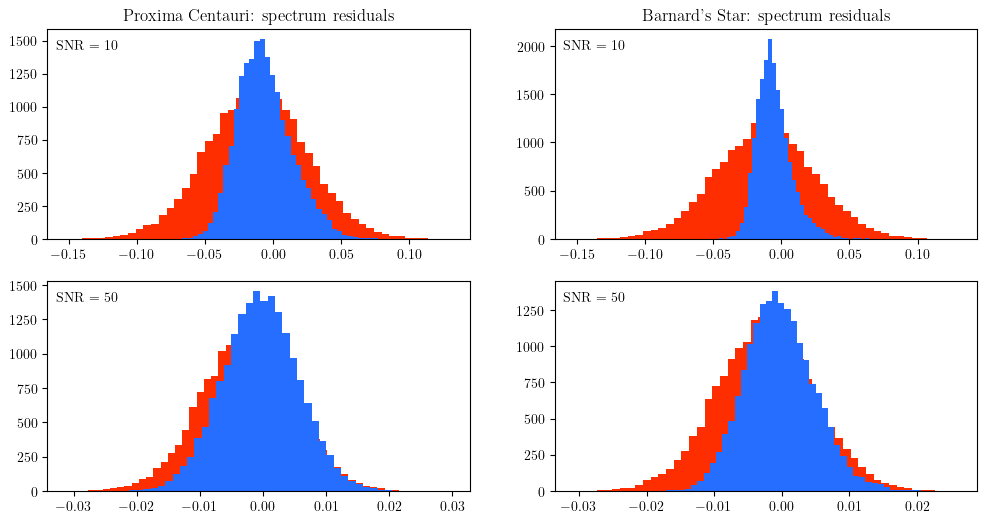

In [78]:
fig, axs = plt.subplots(2, 2, figsize=(12,6))
# plt.subplots_adjust(hspace=0, wspace=0)

template_color   = "#FF2E00"   # warm tone
postellar_color  = "#256EFF"
onesig = "#5C92FF"
twosig = "#85ADFF"
threesig = "#ADC9FF"   # cool tone

def plot_system(ax, system, data_dict):
    data = data_dict[system]['spectrum']
    wavelength = wgrid[start:end]
    true_spec  = data['true_spectrum'][0,0][start:end]
    template   = data['template'][start:end]

    post = data['posterior_spectrum_samples'][:,:,0,non_ones[0]:non_ones[-1]+1][:,:,start:end]
    mean_post = np.percentile(post, 50, axis=(0,1))
    sig1 = np.percentile(post, [16, 84],      axis=(0,1))
    sig2 = np.percentile(post, [2.5, 97.5],   axis=(0,1))
    sig3 = np.percentile(post, [0.15, 99.85], axis=(0,1))

    ax.hist(template-true_spec, bins=50,color=template_color, label="Template")#,lw=2,zorder=0)
    ax.hist(mean_post-true_spec, bins=50,color=postellar_color, label="Postellar")#,lw=2,zorder=4)
    ax.text(0.02, 0.95, f"SNR = {system[1]}", transform=ax.transAxes,
        ha="left", va="top", fontsize=10)


# Row 2 + 3: (0,10,10) and (0,75,10)
plot_system(axs[0,0], (0,10,10), proxima_data)
plot_system(axs[1,0], (0,50,10), proxima_data)
plot_system(axs[0,1], (0,10,10), barnard_data)
plot_system(axs[1,1], (0,50,10), barnard_data)


axs[0,0].set_title("Proxima Centauri: spectrum residuals")
axs[0,1].set_title("Barnard's Star: spectrum residuals")

0.1
(1, 18681) torch.Size([1, 1, 18681])
0.02
(1, 18681) torch.Size([1, 1, 18681])
0.1
(1, 18681) torch.Size([1, 1, 18681])
0.02
(1, 18681) torch.Size([1, 1, 18681])


Text(0.5, 1.0, "Barnard's Star: data residuals")

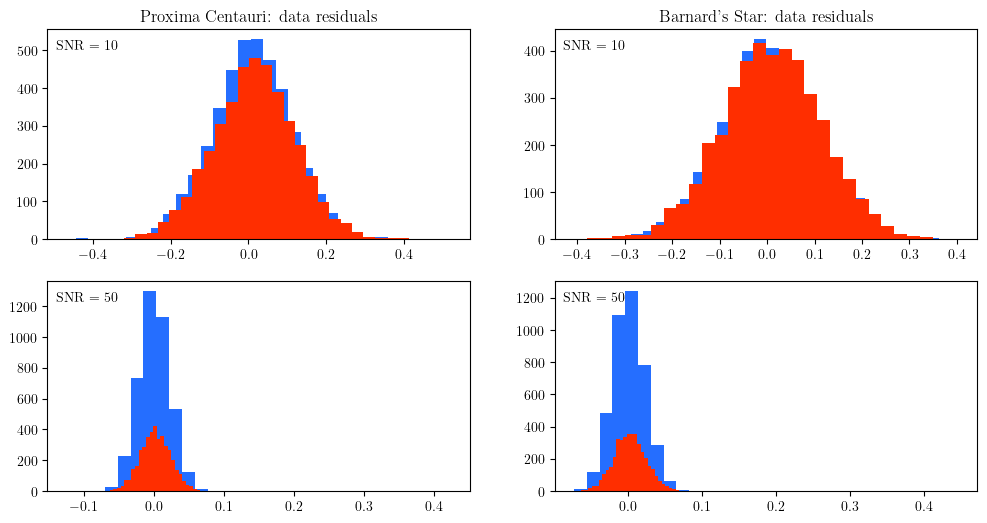

In [79]:
fig, axs = plt.subplots(2, 2, figsize=(12,6))
# plt.subplots_adjust(hspace=0, wspace=0)

template_color   = "#FF2E00"   # warm tone
postellar_color  = "#256EFF"
onesig = "#5C92FF"
twosig = "#85ADFF"
threesig = "#ADC9FF"   # cool tone

def plot_system(ax, system, data_dict):
    data = data_dict[system]['spectrum']
    wavelength = wgrid[start:end]
    true_spec  = data['true_spectrum'][0,0][start:end]
    template   = data['template'][start:end]
    post = data['posterior_spectrum_samples'][:,:,0,non_ones[0]:non_ones[-1]+1][:,:,start:end]

    mean = np.percentile(post, 50, axis=(0,1))
    sigma_1 = np.percentile(post, [16, 84], axis=(0,1))
    sigma_2 = np.percentile(post, [2.5, 97.5], axis=(0,1))
    sigma_3 = np.percentile(post, [0.15, 99.85], axis=(0,1))

    temp_residuals = (true_spec - template)/true_spec
    diff_residuals = (true_spec - mean)/true_spec


    # Data residuals 
    true_specf = data['true_spectrum'][0,0]#,non_ones[0]:non_ones[-1]+1]
    templatef = data['template']
    meanf = data['posterior_spectrum_samples'][:,0,0,non_ones[0]:non_ones[-1]+1]
    wavelengthf = wgrid




    a = torch.tensor(true_specf).unsqueeze(0).unsqueeze(0)
    b = torch.tensor(wavelengthf)
    c = torch.tensor(inst_wgrid)
    print(1/system[1])
    data_forward = (forward_model(a,b,c,torch.tensor([[0]]),torch.tensor([[0]])))[0,0]+(torch.normal(0,1/system[1],inst_wgrid.shape))
    d = torch.tensor(templatef).unsqueeze(0).unsqueeze(0)
    temp_forward = forward_model(d,b,c,torch.tensor([[0]]),torch.tensor([[0]]))[0,0]
    print(meanf.shape, d.shape)
    e = torch.tensor(meanf).unsqueeze(0)
    post_forward = forward_model(e,b,c,torch.tensor([[0]]),torch.tensor([[0]]))[0,0]
    temp_residuals = data_forward - temp_forward
    diff_residuals = data_forward - post_forward

    ax.hist(diff_residuals, bins=30,color=postellar_color, label="Postellar")#,lw=2,zorder=4)
    ax.hist(temp_residuals, bins=30,color=template_color, label="Template")#,lw=2,zorder=0)

    ax.text(0.02, 0.95, f"SNR = {system[1]}", transform=ax.transAxes,
        ha="left", va="top", fontsize=10)


# Row 2 + 3: (0,10,10) and (0,75,10)
plot_system(axs[0,0], (0,10,10), proxima_data)
plot_system(axs[1,0], (0,50,10), proxima_data)
plot_system(axs[0,1], (0,10,10), barnard_data)
plot_system(axs[1,1], (0,50,10), barnard_data)


axs[0,0].set_title("Proxima Centauri: data residuals")
axs[0,1].set_title("Barnard's Star: data residuals")

In [80]:
1/50

0.02